# VW Price Prediction - XGBoost

Let's start by importing necessary packages.

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy.sparse import issparse

Now read in the dataframe and prepare it for use with `XGBoost`.

In [71]:
df = pd.read_parquet("../all_car_details_cleaned.parquet")

## Preparing Data for XGBoost

Let's first drop useless columns.

In [72]:
columns_to_drop = [
    "url",
    "num_images",
    "general_inspection",
    "emission_class",
    "comfort_and_convenience",
    "safety_and_security",
    "entertainment_and_media",
    "extras",
    "paint",
]


df.drop(columns=columns_to_drop, errors="ignore", inplace=True)

Let's only keep VW branded cars.

In [73]:
df = df[df["make"] == "volkswagen"]
df = df.drop("make", axis=1)
df["car_title"].value_counts()

car_title
Volkswagen Golf              3636
Volkswagen Polo              2819
Volkswagen Golf GTI          1278
Volkswagen Tiguan            1242
Volkswagen Passat Variant    1236
                             ... 
Volkswagen T7 California        1
Skoda Citigo                    1
Volkswagen T3 Blue Star         1
Volkswagen Polo Sedan           1
Volkswagen Polo Variant         1
Name: count, Length: 108, dtype: int64

Now we may try and only keep the Volkswagen Golf - and its variants, which seem to be the most popular car title.

In [74]:
df_all_golfs = df[df["car_title"].str.startswith("Volkswagen Golf")]
df_base_golf = df_all_golfs[df["car_title"] == "Volkswagen Golf"]

df_all_golfs["car_title"].value_counts()

C:\Users\david\AppData\Local\Temp\ipykernel_7608\341487499.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_base_golf = df_all_golfs[df["car_title"] == "Volkswagen Golf"]


car_title
Volkswagen Golf              3636
Volkswagen Golf GTI          1278
Volkswagen Golf R             337
Volkswagen Golf Variant       254
Volkswagen Golf Cabriolet     206
Volkswagen Golf GTD           177
Volkswagen Golf Sportsvan     104
Volkswagen Golf GTE           103
Volkswagen Golf Plus           85
Name: count, dtype: int64

Let's do a price boxplot of the two dataframe's prices.

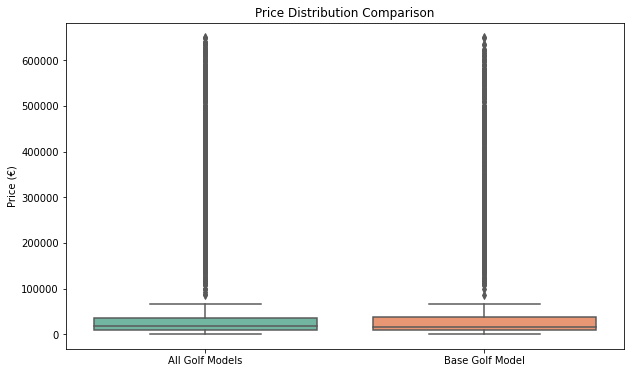

(6180, 25)
(3636, 25)


In [75]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=[df_all_golfs["price"], df_base_golf["price"]], 
            palette="Set2")
plt.xticks([0, 1], ['All Golf Models', 'Base Golf Model'])
plt.title('Price Distribution Comparison')
plt.ylabel('Price (€)')
plt.show()

print(df_all_golfs.shape)
print(df_base_golf.shape)

We can see that the distribution of prices is very skewed. Let's do a harsh 1.5 IQR clean on them.

In [76]:
# Function to remove outliers based on IQR for a specific group
def remove_outliers_iqr(group):
    Q1 = group['price'].quantile(0.25)
    Q3 = group['price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group[(group['price'] >= lower_bound) & (group['price'] <= upper_bound)]

# Apply outlier removal to all Golf models grouped by car_title
df_all_golfs = df_all_golfs.groupby('car_title').apply(remove_outliers_iqr).reset_index(drop=True)

# Apply outlier removal to base Golf model (single group)
Q1 = df_base_golf['price'].quantile(0.25)
Q3 = df_base_golf['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_base_golf = df_base_golf[(df_base_golf['price'] >= lower_bound) & (df_base_golf['price'] <= upper_bound)]

print(df_all_golfs.shape)
print(df_base_golf.shape)

(5133, 25)
(2838, 25)


C:\Users\david\AppData\Local\Temp\ipykernel_7608\2693958348.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_golfs = df_all_golfs.groupby('car_title').apply(remove_outliers_iqr).reset_index(drop=True)


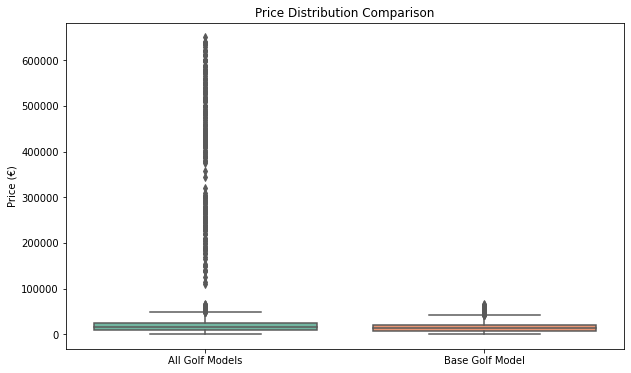

In [77]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=[df_all_golfs["price"], df_base_golf["price"]], 
            palette="Set2")
plt.xticks([0, 1], ['All Golf Models', 'Base Golf Model'])
plt.title('Price Distribution Comparison')
plt.ylabel('Price (€)')
plt.show()

We can see that even after the 1.5 IQR removal there are a bunch of outliers for the "All Golf Models" dataframe, supposedly the more unique and GTI models.

Now since XGBoost does not need any scaling, imputing of missing values or turning to tensors, let's start by splitting to ensure no data leakage happens and then split the dataset before applying OHE.

In [78]:
X_all_golfs = df_all_golfs.drop("price", axis=1)
y_all_golfs = df_all_golfs["price"]
X_all_golfs_train, X_all_golfs_test, y_all_golfs_train, y_all_golfs_test = (
    train_test_split(X_all_golfs, y_all_golfs, test_size=0.2, random_state=42)
)

x_base_golf = df_base_golf.drop("price", axis=1)
y_base_golf = df_base_golf["price"]
X_base_golf_train, X_base_golf_test, y_base_golf_train, y_base_golf_test = (
    train_test_split(x_base_golf, y_base_golf, test_size=0.2, random_state=42)
)

In [79]:
# --- 6. Preprocessing with ColumnTransformer ---
# XGBoost handles NaNs in numerical features. For categorical, OHE needs a strategy.
# We fill NaNs in categorical columns before OHE for simplicity here.
print("Filling NaNs in categorical features with 'Missing_Cat_Value'...")
categorical_features_all = [
    col
    for col in X_all_golfs_train.select_dtypes(include=["object", "category"]).columns
]
# It's generally safer to work on copies when modifying DataFrames to avoid SettingWithCopyWarning,
# especially if X_all_golfs_train is a slice. However, for this refactoring, I'll keep your current approach.
# If warnings appear, consider using .copy() e.g., X_all_golfs_train = X_all_golfs_train.copy()
for col in categorical_features_all:
    if col in X_all_golfs_train.columns:
        X_all_golfs_train.loc[:, col] = X_all_golfs_train[col].fillna(
            "Missing_Cat_Value"
        )
    if col in X_all_golfs_test.columns:
        X_all_golfs_test.loc[:, col] = X_all_golfs_test[col].fillna("Missing_Cat_Value")

categorical_features_base = [
    col
    for col in X_base_golf_train.select_dtypes(include=["object", "category"]).columns
]
for col in categorical_features_base:
    if col in X_base_golf_train.columns:
        X_base_golf_train.loc[:, col] = X_base_golf_train[col].fillna(
            "Missing_Cat_Value"
        )
    if col in X_base_golf_test.columns:
        X_base_golf_test.loc[:, col] = X_base_golf_test[col].fillna("Missing_Cat_Value")

print("NaNs filled in categorical features.")


# Define the ColumnTransformer
# Numerical features will pass through as XGBoost handles their NaNs and doesn't require scaling.
preprocessor_all = ColumnTransformer(
    transformers=[
        (
            "ohe",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop=None
            ),  # MODIFIED: sparse_output=False
            categorical_features_all,
        )
    ],
    remainder="passthrough",  # Keep numerical columns not specified in transformers
)
preprocessor_base = ColumnTransformer(
    transformers=[
        (
            "ohe",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop=None
            ),  # MODIFIED: sparse_output=False
            categorical_features_base,
        )
    ],
    remainder="passthrough",  # Keep numerical columns not specified in transformers
)

# Fit the preprocessor on X_train and transform both train and test sets
# The output will be a NumPy array, which we'll convert to a DataFrame.

# For all_golfs
X_train_all_golfs_np = preprocessor_all.fit_transform(X_all_golfs_train)
# Use get_feature_names_out() to get the column names directly
final_feature_names_all = preprocessor_all.get_feature_names_out()
X_train_final_all_golfs_df = pd.DataFrame(
    X_train_all_golfs_np, columns=final_feature_names_all, index=X_all_golfs_train.index
)

X_test_all_golfs_np = preprocessor_all.transform(X_all_golfs_test)
X_test_final_all_golfs_df = pd.DataFrame(
    X_test_all_golfs_np, columns=final_feature_names_all, index=X_all_golfs_test.index
)

print(f"Processed 'all_golfs' training data shape: {X_train_final_all_golfs_df.shape}")
print(f"Processed 'all_golfs' test data shape: {X_test_final_all_golfs_df.shape}")


# For base_golf
X_train_base_golf_np = preprocessor_base.fit_transform(X_base_golf_train)
final_feature_names_base = preprocessor_base.get_feature_names_out()
X_train_final_base_golf_df = pd.DataFrame(
    X_train_base_golf_np,
    columns=final_feature_names_base,
    index=X_base_golf_train.index,
)

X_test_base_golf_np = preprocessor_base.transform(X_base_golf_test)
X_test_final_base_golf_df = pd.DataFrame(
    X_test_base_golf_np, columns=final_feature_names_base, index=X_base_golf_test.index
)

print(f"Processed 'base_golf' training data shape: {X_train_final_base_golf_df.shape}")
print(f"Processed 'base_golf' test data shape: {X_test_final_base_golf_df.shape}")

print("\nFirst 5 rows of processed 'all_golfs' training DataFrame:")
print(X_train_final_all_golfs_df.head())
# print("\nFirst 5 rows of processed 'base_golf' training DataFrame:")
# print(X_train_final_base_golf_df.head())

Filling NaNs in categorical features with 'Missing_Cat_Value'...
NaNs filled in categorical features.
Processed 'all_golfs' training data shape: (4106, 123)
Processed 'all_golfs' test data shape: (1027, 123)
Processed 'base_golf' training data shape: (2270, 107)
Processed 'base_golf' test data shape: (568, 107)

First 5 rows of processed 'all_golfs' training DataFrame:
      ohe__car_title_Volkswagen Golf  \
3331                             0.0   
949                              1.0   
3738                             0.0   
19                               1.0   
4006                             0.0   

      ohe__car_title_Volkswagen Golf Cabriolet  \
3331                                       0.0   
949                                        0.0   
3738                                       0.0   
19                                         0.0   
4006                                       0.0   

      ohe__car_title_Volkswagen Golf GTD  ohe__car_title_Volkswagen Golf GTE  \
3331  

In [80]:
print(X_train_final_all_golfs_df.shape)
print(X_train_final_base_golf_df.shape)

(4106, 123)
(2270, 107)


## Baseline XGBoost Model Training

Now we'll train baseline XGBoost models on the preprocessed DataFrames for both `all_golfs` and `base_golf` datasets.

In [81]:
# --- Train Baseline XGBoost model for 'all_golfs' ---
print("--- Training Baseline XGBoost for 'all_golfs' ---")
xgb_model_all_golfs_baseline = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,             # A common baseline starting point
    learning_rate=0.1,            # A common baseline starting point
    max_depth=5,                  # A common baseline starting point
    subsample=0.8,                # Fraction of samples used for fitting the individual base learners
    colsample_bytree=0.8,         # Fraction of features used for fitting the individual base learners
    random_state=42,
    n_jobs=-1,                     # Use all available cores
    early_stopping_rounds=10,
    eval_metric='mae'
)

xgb_model_all_golfs_baseline.fit(
    X_train_final_all_golfs_df, y_all_golfs_train,
    eval_set=[(X_test_final_all_golfs_df, y_all_golfs_test)],
    verbose=False                 # Set to True or a number (e.g., 50) to see training progress
)
print("Training for 'all_golfs' (baseline) complete.")

# --- Evaluate 'all_golfs' baseline model ---
y_pred_train_all_golfs_baseline = xgb_model_all_golfs_baseline.predict(X_train_final_all_golfs_df)
y_pred_test_all_golfs_baseline = xgb_model_all_golfs_baseline.predict(X_test_final_all_golfs_df)

print("\nMetrics for 'all_golfs' (Baseline Model):")
print("Training Set:")
print(f"  MAE:  {mean_absolute_error(y_all_golfs_train, y_pred_train_all_golfs_baseline):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_all_golfs_train, y_pred_train_all_golfs_baseline)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_all_golfs_train, y_pred_train_all_golfs_baseline):.2f}")
print(f"  R²:   {r2_score(y_all_golfs_train, y_pred_train_all_golfs_baseline):.4f}")

print("Test Set:")
print(f"  MAE:  {mean_absolute_error(y_all_golfs_test, y_pred_test_all_golfs_baseline):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_all_golfs_test, y_pred_test_all_golfs_baseline)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_all_golfs_test, y_pred_test_all_golfs_baseline):.2f}")
print(f"  R²:   {r2_score(y_all_golfs_test, y_pred_test_all_golfs_baseline):.4f}")

# Feature importance for 'all_golfs' baseline
# plt.figure(figsize=(10, 12))
# xgb.plot_importance(xgb_model_all_golfs_baseline, max_num_features=20, title="Feature Importance - All Golfs (Baseline)")
# plt.tight_layout()
# plt.show()

--- Training Baseline XGBoost for 'all_golfs' ---
Training for 'all_golfs' (baseline) complete.

Metrics for 'all_golfs' (Baseline Model):
Training Set:
  MAE:  5616.86
  MAPE: 39.43%
  MSE:  256718965.93
  R²:   0.9671
Test Set:
  MAE:  9812.99
  MAPE: 49.75%
  MSE:  1230454014.61
  R²:   0.8708


In [82]:
# --- Train Baseline XGBoost model for 'base_golf' ---
print("\n--- Training Baseline XGBoost for 'base_golf' ---")
xgb_model_base_golf_baseline = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=10,
    eval_metric='mae'
)

xgb_model_base_golf_baseline.fit(
    X_train_final_base_golf_df, y_base_golf_train,
    eval_set=[(X_test_final_base_golf_df, y_base_golf_test)],
    verbose=False
)
print("Training for 'base_golf' (baseline) complete.")

# --- Evaluate 'base_golf' baseline model ---
y_pred_train_base_golf_baseline = xgb_model_base_golf_baseline.predict(X_train_final_base_golf_df)
y_pred_test_base_golf_baseline = xgb_model_base_golf_baseline.predict(X_test_final_base_golf_df)

print("\nMetrics for 'base_golf' (Baseline Model):")
print("Training Set:")
print(f"  MAE:  {mean_absolute_error(y_base_golf_train, y_pred_train_base_golf_baseline):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_base_golf_train, y_pred_train_base_golf_baseline)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_base_golf_train, y_pred_train_base_golf_baseline):.2f}")
print(f"  R²:   {r2_score(y_base_golf_train, y_pred_train_base_golf_baseline):.4f}")

print("Test Set:")
print(f"  MAE:  {mean_absolute_error(y_base_golf_test, y_pred_test_base_golf_baseline):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_base_golf_test, y_pred_test_base_golf_baseline)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_base_golf_test, y_pred_test_base_golf_baseline):.2f}")
print(f"  R²:   {r2_score(y_base_golf_test, y_pred_test_base_golf_baseline):.4f}")

# Feature importance for 'base_golf' baseline
# plt.figure(figsize=(10, 12))
# xgb.plot_importance(xgb_model_base_golf_baseline, max_num_features=20, title="Feature Importance - Base Golf (Baseline)")
# plt.tight_layout()
# plt.show()


--- Training Baseline XGBoost for 'base_golf' ---
Training for 'base_golf' (baseline) complete.

Metrics for 'base_golf' (Baseline Model):
Training Set:
  MAE:  1389.46
  MAPE: 17.49%
  MSE:  4306219.09
  R²:   0.9623
Test Set:
  MAE:  2154.74
  MAPE: 26.99%
  MSE:  14752762.67
  R²:   0.8830


## Hyperparameter Tuning


--- Starting Comprehensive Hyperparameter Tuning for 'all_golfs' ---
Fitting 3 folds for each of 75 candidates, totalling 225 fits


c:\Users\david\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Hyperparameter tuning for 'all_golfs' complete.
Best parameters found:  {'colsample_bylevel': 0.8603553891795411, 'colsample_bynode': 0.6225646316108401, 'colsample_bytree': 0.8887995089067299, 'gamma': 0.4692763545078751, 'learning_rate': 0.010225842093894155, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 559, 'reg_alpha': 0.6116531604882809, 'reg_lambda': 0.007066305219717406, 'subsample': 0.6092249700165663}
Best R2 score found during tuning:  -8637.271081347477

Metrics for Best Tuned 'all_golfs' Model:
Training Set:
  MAE:  2996.59
  MAPE: 22.97%
  MSE:  38246625.51
  R²:   0.9951
Test Set:
  MAE:  9015.96
  MAPE: 36.45%
  MSE:  1174102816.20
  R²:   0.8768


<Figure size 720x864 with 0 Axes>

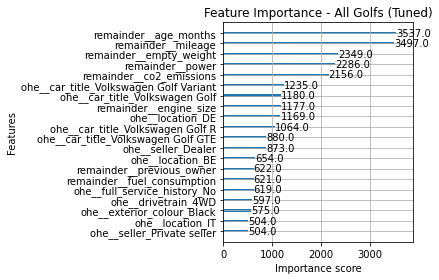

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
# This is a comprehensive set; adjust ranges if needed based on initial observations or domain knowledge.
param_dist_all_golfs = {
    'n_estimators': randint(100, 1500),        # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.29),     # Step size shrinkage (0.01 to 0.3 effectively)
    'max_depth': randint(3, 12),              # Maximum depth of a tree
    'min_child_weight': randint(1, 10),       # Minimum sum of instance weight needed in a child
    'gamma': uniform(0, 0.5),                 # Minimum loss reduction required to make a further partition
    'subsample': uniform(0.6, 0.4),           # Subsample ratio of the training instance (0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4),    # Subsample ratio of columns when constructing each tree (0.6 to 1.0)
    'colsample_bylevel': uniform(0.6, 0.4),   # Subsample ratio of columns for each level (0.6 to 1.0)
    'colsample_bynode': uniform(0.6, 0.4),    # Subsample ratio of columns for each split (0.6 to 1.0)
    'reg_alpha': uniform(0, 1),               # L1 regularization term on weights
    'reg_lambda': uniform(0, 1)               # L2 regularization term on weights
}

# Initialize the XGBRegressor (hyperparameters will be set by RandomizedSearchCV)
xgb_tuning_all_golfs = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=15,
    eval_metric='mae'
    # early_stopping_rounds will be passed via fit_params to RandomizedSearchCV if needed,
    # or applied when refitting the best model.
)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled.
# cv: Determines the cross-validation splitting strategy.
# Scoring: Use a metric where higher is better. For MAE/MSE, use 'neg_mean_absolute_error', etc.
# For R^2, 'r2' is fine.
rf_search_all_golfs = RandomizedSearchCV(
    estimator=xgb_tuning_all_golfs,
    param_distributions=param_dist_all_golfs,
    n_iter=75,  # Increase for more comprehensive search (e.g., 50-150)
    cv=3,       # 5-fold cross-validation
    scoring='neg_mean_absolute_error',
    verbose=2,  # Shows progress
    random_state=42,
    n_jobs=-1   # Use all available cores for CV too
    # refit=True by default, so it will refit the best estimator on the whole training data
)

print("\n--- Starting Comprehensive Hyperparameter Tuning for 'all_golfs' ---")
# Define fit_params if you want to use early stopping within RandomizedSearchCV's CV folds
# This can speed up evaluation of poor parameter sets.
fit_params_all_golfs = {
    'eval_set': [(X_test_final_all_golfs_df, y_all_golfs_test)],
    'verbose': False
}

rf_search_all_golfs.fit(X_train_final_all_golfs_df, y_all_golfs_train, **fit_params_all_golfs)

print("\nHyperparameter tuning for 'all_golfs' complete.")
print("Best parameters found: ", rf_search_all_golfs.best_params_)
print("Best neg_mean_absolute_error score found during tuning: ", rf_search_all_golfs.best_score_)

# Get the best model
best_xgb_model_all_golfs = rf_search_all_golfs.best_estimator_

# --- Evaluate the best model from tuning ---
# Note: If refit=True (default), best_xgb_model_all_golfs is already refitted on the entire X_train_final_all_golfs_df.
# If you used early stopping in fit_params with eval_set pointing to the test set,
# the `best_estimator_` will have been trained with early stopping based on that test set.
# For a truly unbiased final evaluation, you'd ideally have a third, hold-out test set
# or be mindful of this when interpreting final test scores.

y_pred_train_best_all_golfs = best_xgb_model_all_golfs.predict(X_train_final_all_golfs_df)
y_pred_test_best_all_golfs = best_xgb_model_all_golfs.predict(X_test_final_all_golfs_df)

print("\nMetrics for Best Tuned 'all_golfs' Model:")
print("Training Set:")
print(f"  MAE:  {mean_absolute_error(y_all_golfs_train, y_pred_train_best_all_golfs):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_all_golfs_train, y_pred_train_best_all_golfs)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_all_golfs_train, y_pred_train_best_all_golfs):.2f}")
print(f"  R²:   {r2_score(y_all_golfs_train, y_pred_train_best_all_golfs):.4f}")

print("Test Set:")
print(f"  MAE:  {mean_absolute_error(y_all_golfs_test, y_pred_test_best_all_golfs):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_all_golfs_test, y_pred_test_best_all_golfs)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_all_golfs_test, y_pred_test_best_all_golfs):.2f}")
print(f"  R²:   {r2_score(y_all_golfs_test, y_pred_test_best_all_golfs):.4f}")

# Feature importance for the best tuned 'all_golfs' model
plt.figure(figsize=(10, 12))
xgb.plot_importance(best_xgb_model_all_golfs, max_num_features=20, title="Feature Importance - All Golfs (Tuned)")
plt.tight_layout()
plt.show()


--- Starting Comprehensive Hyperparameter Tuning for 'base_golf' ---
Fitting 3 folds for each of 100 candidates, totalling 300 fits

Hyperparameter tuning for 'base_golf' complete.
Best parameters found:  {'colsample_bylevel': 0.6944466132469618, 'colsample_bynode': 0.9039821635750342, 'colsample_bytree': 0.8125063015894136, 'gamma': 0.3602580306957324, 'learning_rate': 0.028078995128260016, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 1130, 'reg_alpha': 0.6871655054033311, 'reg_lambda': 0.8444406726336288, 'subsample': 0.8998464928034349}
Best R2 score found during tuning:  -1997.9345630699088

Metrics for Best Tuned 'base_golf' Model:
Training Set:
  MAE:  563.78
  MAPE: 8.60%
  MSE:  989554.54
  R²:   0.9913
Test Set:
  MAE:  2035.60
  MAPE: 25.32%
  MSE:  13413777.77
  R²:   0.8936


<Figure size 720x864 with 0 Axes>

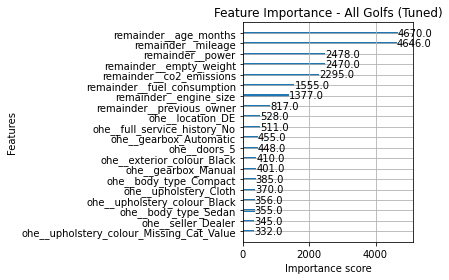

In [84]:
# Define the parameter distribution for RandomizedSearchCV
# This is a comprehensive set; adjust ranges if needed based on initial observations or domain knowledge.
param_dist_base_golf = {
    'n_estimators': randint(100, 2000),        # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.29),     # Step size shrinkage (0.01 to 0.3 effectively)
    'max_depth': randint(3, 12),              # Maximum depth of a tree
    'min_child_weight': randint(1, 10),       # Minimum sum of instance weight needed in a child
    'gamma': uniform(0, 0.5),                 # Minimum loss reduction required to make a further partition
    'subsample': uniform(0.6, 0.4),           # Subsample ratio of the training instance (0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4),    # Subsample ratio of columns when constructing each tree (0.6 to 1.0)
    'colsample_bylevel': uniform(0.6, 0.4),   # Subsample ratio of columns for each level (0.6 to 1.0)
    'colsample_bynode': uniform(0.6, 0.4),    # Subsample ratio of columns for each split (0.6 to 1.0)
    'reg_alpha': uniform(0, 1),               # L1 regularization term on weights
    'reg_lambda': uniform(0, 1)               # L2 regularization term on weights
}

# Initialize the XGBRegressor (hyperparameters will be set by RandomizedSearchCV)
xgb_tuning_base_golf = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=15,
    eval_metric='mae'
    # early_stopping_rounds will be passed via fit_params to RandomizedSearchCV if needed,
    # or applied when refitting the best model.
)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled.
# cv: Determines the cross-validation splitting strategy.
# Scoring: Use a metric where higher is better. For MAE/MSE, use 'neg_mean_absolute_error', etc.
# For R^2, 'r2' is fine.
rf_search_base_golf = RandomizedSearchCV(
    estimator=xgb_tuning_base_golf,
    param_distributions=param_dist_base_golf,
    n_iter=100,  # Increase for more comprehensive search (e.g., 50-150)
    cv=3,       # 5-fold cross-validation
    scoring='neg_mean_absolute_error',
    verbose=2,  # Shows progress
    random_state=42,
    n_jobs=-1   # Use all available cores for CV too
    # refit=True by default, so it will refit the best estimator on the whole training data
)

print("\n--- Starting Comprehensive Hyperparameter Tuning for 'base_golf' ---")
# Define fit_params if you want to use early stopping within RandomizedSearchCV's CV folds
# This can speed up evaluation of poor parameter sets.
fit_params_base_golf = {
    'eval_set': [(X_test_final_base_golf_df, y_base_golf_test)],
    'verbose': False
}

rf_search_base_golf.fit(X_train_final_base_golf_df, y_base_golf_train, **fit_params_base_golf)

print("\nHyperparameter tuning for 'base_golf' complete.")
print("Best parameters found: ", rf_search_base_golf.best_params_)
print("Best neg_mean_absolute_error score found during tuning: ", rf_search_base_golf.best_score_)

# Get the best model
best_xgb_model_base_golf = rf_search_base_golf.best_estimator_

# --- Evaluate the best model from tuning ---
# Note: If refit=True (default), best_xgb_model_base_golf is already refitted on the entire X_train_final_base_golf_df.
# If you used early stopping in fit_params with eval_set pointing to the test set,
# the `best_estimator_` will have been trained with early stopping based on that test set.
# For a truly unbiased final evaluation, you'd ideally have a third, hold-out test set
# or be mindful of this when interpreting final test scores.

y_pred_train_best_base_golf = best_xgb_model_base_golf.predict(X_train_final_base_golf_df)
y_pred_test_best_base_golf = best_xgb_model_base_golf.predict(X_test_final_base_golf_df)

print("\nMetrics for Best Tuned 'base_golf' Model:")
print("Training Set:")
print(f"  MAE:  {mean_absolute_error(y_base_golf_train, y_pred_train_best_base_golf):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_base_golf_train, y_pred_train_best_base_golf)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_base_golf_train, y_pred_train_best_base_golf):.2f}")
print(f"  R²:   {r2_score(y_base_golf_train, y_pred_train_best_base_golf):.4f}")

print("Test Set:")
print(f"  MAE:  {mean_absolute_error(y_base_golf_test, y_pred_test_best_base_golf):.2f}")
print(f"  MAPE: {mean_absolute_percentage_error(y_base_golf_test, y_pred_test_best_base_golf)*100:.2f}%")
print(f"  MSE:  {mean_squared_error(y_base_golf_test, y_pred_test_best_base_golf):.2f}")
print(f"  R²:   {r2_score(y_base_golf_test, y_pred_test_best_base_golf):.4f}")

# Feature importance for the best tuned 'base_golf' model
plt.figure(figsize=(10, 12))
xgb.plot_importance(best_xgb_model_base_golf, max_num_features=20, title="Feature Importance - All Golfs (Tuned)")
plt.tight_layout()
plt.show()

### Predicted VS Actual - Residual Plots

### All Golfs

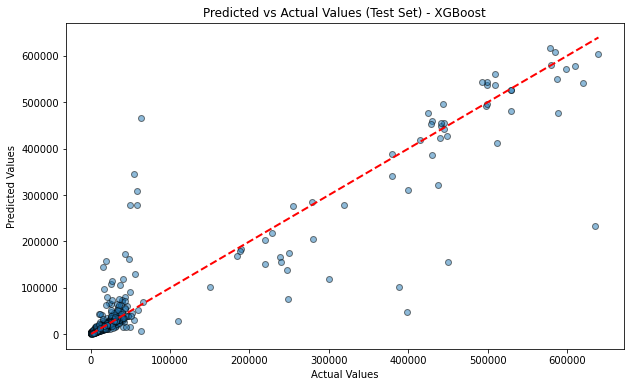

In [85]:
plt.figure(figsize=(10, 6))
plt.scatter(y_all_golfs_test, y_pred_test_best_all_golfs, alpha=0.5, edgecolors="k")
plt.plot([y_all_golfs_test.min(), y_all_golfs_test.max()], [y_all_golfs_test.min(), y_all_golfs_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values (Test Set) - XGBoost")
plt.show()

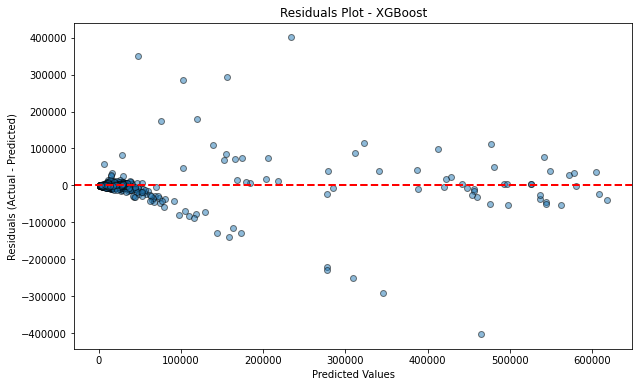

In [94]:
residuals = y_all_golfs_test - y_pred_test_best_all_golfs

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_best_all_golfs, residuals, alpha=0.5, edgecolors="k")
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot - XGBoost")
plt.show()

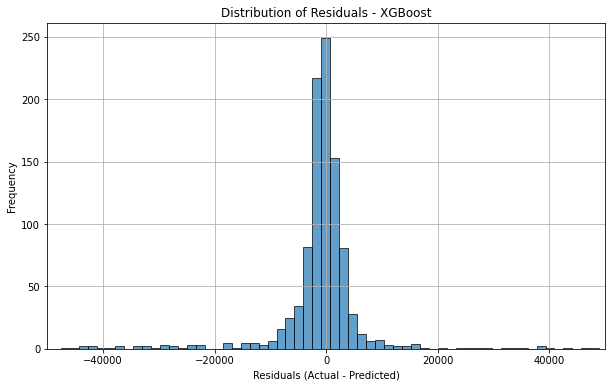

In [97]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=500, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals - XGBoost')
plt.grid(True)
plt.xlim(-50000, 50000)
plt.show()

### Base Golf

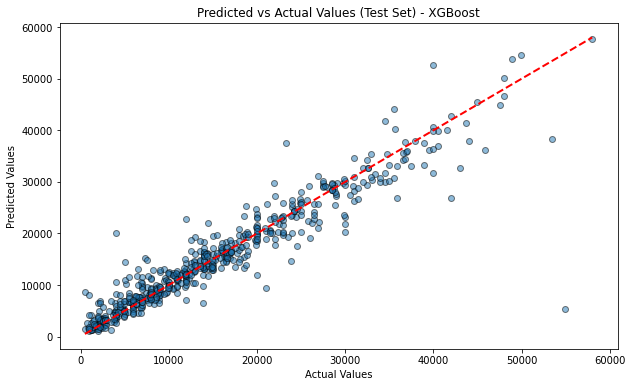

In [88]:
plt.figure(figsize=(10, 6))
plt.scatter(y_base_golf_test, y_pred_test_best_base_golf, alpha=0.5, edgecolors="k")
plt.plot([y_base_golf_test.min(), y_base_golf_test.max()], [y_base_golf_test.min(), y_base_golf_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values (Test Set) - XGBoost")
plt.show()

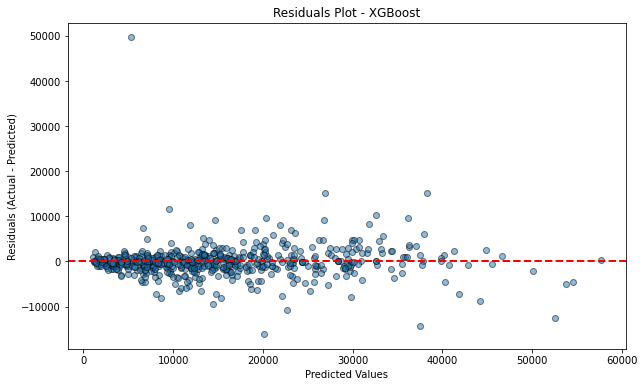

In [89]:
residuals = y_base_golf_test - y_pred_test_best_base_golf

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_best_base_golf, residuals, alpha=0.5, edgecolors="k")
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot - XGBoost")
plt.show()

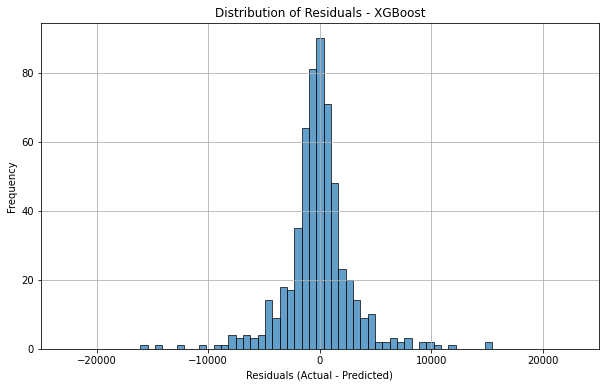

In [91]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals - XGBoost')
plt.grid(True)
plt.xlim(-25000, 25000)
plt.show()

### Feature Importance